===========================IPL DATA ANALYSIS================================

This project analyzes IPL historical data using Python, Pandas, Matplotlib, and Seaborn. The objective is to uncover trends in team performance, batting records, bowling achievements, scoring patterns, and match outcomes through exploratory data analysis.

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
print("Libraries ready! ")

Libraries ready! 


In [15]:
# Load data
df_matches = pd.read_csv('/content/drive/MyDrive/ipl_matches_data.csv')
df_balls = pd.read_csv('/content/drive/MyDrive/ball_by_ball_data.csv')
df_player = pd.read_csv('/content/drive/MyDrive/players-data-updated.csv')
df_team_aliases = pd.read_csv('/content/drive/MyDrive/team_aliases.csv')
df_team = pd.read_csv('/content/drive/MyDrive/teams_data.csv')

print(" Matches:", len(df_matches))
print(" Balls:", len(df_balls))

 Matches: 1212
 Balls: 288226


In [16]:
print("==========Matches============")
df_matches.head()

==========Matches============


,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,result,player_of_match
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,win,46.0
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,win,15.0
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,win,36.0
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,win,57.0
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,win,71.0


In [17]:
df_balls.groupby("season_id")["match_id"].count()

,match_id
season_id,
2008,13489
2009,13606
2010,14498
2011,17013
2012,17767
2013,18177
2014,14300
2015,13652
2016,14096


In [18]:
# Sort matches data by season and date
df_matches = df_matches.sort_values(
    by=['season', 'match_date']
).reset_index(drop=True)

# Check if sorted correctly
print("First 5 rows after sorting:")
df_matches.head()

First 5 rows after sorting:


,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,result,player_of_match
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,win,46.0
1,335983,2008,6,Chandigarh,2008-04-19,Indian Premier League,2.0,male,T20,T20,...,"Punjab Cricket Association Stadium, Mohali",129,494,129,bat,129,33.0,NaN,win,11943.0
2,335984,2008,6,Delhi,2008-04-19,Indian Premier League,3.0,male,T20,T20,...,Feroz Shah Kotla,134,252,134,bat,252,NaN,9.0,win,11982.0
3,335985,2008,6,Mumbai,2008-04-20,Indian Premier League,5.0,male,T20,T20,...,Wankhede Stadium,3,3,1,bat,1,NaN,5.0,win,11935.0
4,335986,2008,6,Kolkata,2008-04-20,Indian Premier League,4.0,male,T20,T20,...,Eden Gardens,2,6,2,bat,6,NaN,5.0,win,11922.0


In [19]:
df_balls = df_balls.sort_values(
    by=['season_id', 'match_id']
).reset_index(drop=True)
df_balls.head(300)

,season_id,match_id,batter,bowler,non_striker,team_batting,team_bowling,over_number,ball_number,batter_runs,...,is_bye,is_penalty,wide_ball_runs,no_ball_runs,leg_bye_runs,bye_runs,penalty_runs,wicket_kind,is_super_over,innings
0,2008,335982,SC Ganguly,P Kumar,BB McCullum,6,1,0,0,0,...,False,False,0,0,1,0,0,NaN,False,1
1,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,1,0,...,False,False,0,0,0,0,0,NaN,False,1
2,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,2,0,...,False,False,1,0,0,0,0,NaN,False,1
3,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,3,0,...,False,False,0,0,0,0,0,NaN,False,1
4,2008,335982,BB McCullum,P Kumar,SC Ganguly,6,1,0,4,0,...,False,False,0,0,0,0,0,NaN,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2008,335983,MEK Hussey,K Goel,SK Raina,129,494,11,2,1,...,False,False,0,0,0,0,0,NaN,False,1
296,2008,335983,SK Raina,K Goel,MEK Hussey,129,494,11,3,6,...,False,False,0,0,0,0,0,NaN,False,1
297,2008,335983,SK Raina,K Goel,MEK Hussey,129,494,11,4,1,...,False,False,0,0,0,0,0,NaN,False,1
298,2008,335983,MEK Hussey,K Goel,SK Raina,129,494,11,5,2,...,False,False,0,0,0,0,0,NaN,False,1


=========Finding missing values in matches=======

In [20]:
print(df_matches.isnull().sum())

match_id             0
season_id            0
balls_per_over       0
city                51
match_date           0
event_name           0
match_number        70
gender               0
match_type           0
format               0
overs                0
season               0
team_type            0
venue                0
toss_winner          0
team1                0
team2                0
toss_decision        0
match_winner         0
win_by_runs        666
win_by_wickets     571
result               0
player_of_match      9
dtype: int64


 Data Cleaning


 Fix 1 — Fill missing city with "Unknown"

In [21]:
df_matches['city']=df_matches['city'].fillna('Unknown')

Fix 2 — Fill missing player of match with "Unknown"

In [22]:
df_matches['player_of_match']=df_matches['player_of_match'].fillna('Unkonwn')

Fix 3 — Fill win_by_runs and win_by_wickets with 0

In [23]:
df_matches['win_by_runs']=df_matches['win_by_runs'].fillna(0)
df_matches['win_by_wickets']=df_matches['win_by_wickets'].fillna(0)

Fix 4 — Fill match_number with 0

In [24]:
df_matches['match_number']=df_matches['match_number'].fillna(0)

In [25]:
df_matches.isnull().sum()

,0
match_id,0
season_id,0
balls_per_over,0
city,0
match_date,0
event_name,0
match_number,0
gender,0
match_type,0
format,0


 Check missing values in balls data

In [26]:
df_balls.isnull().sum()

,0
season_id,0
match_id,0
batter,0
bowler,0
non_striker,0
team_batting,0
team_bowling,0
over_number,0
ball_number,0
batter_runs,0


Fix missing batsman and bowler type

In [27]:
df_balls['batsman_type']= df_balls['batsman_type'].fillna('Unknown')
df_balls['bowler_type']= df_balls['bowler_type'].fillna('Unknown')

Fill wicket related columns with "None"

In [28]:
df_balls['player_out']=df_balls['player_out'].fillna('None')
df_balls['fielders_involved']=df_balls['fielders_involved'].fillna('None')
df_balls['wicket_kind'] = df_balls['wicket_kind'].fillna('None')
df_balls.isnull().sum()


,0
season_id,0
match_id,0
batter,0
bowler,0
non_striker,0
team_batting,0
team_bowling,0
over_number,0
ball_number,0
batter_runs,0


**Analysis 1:** Most Fours Hit by a Player in Every Season

**Objective**
Identify the player who hit the most fours in each IPL season.

In [29]:
fours = df_balls[df_balls["batter_runs"] == 4]
season_fours = (
    fours.groupby(["season_id", "batter"])
    .size()
    .reset_index(name="fours")
)
top_four_hitters = (
    season_fours.loc[
        season_fours.groupby("season_id")["fours"].idxmax()
    ]
)

top_four_hitters

,season_id,batter,fours
28,2008,G Gambhir,68
176,2009,ML Hayden,60
334,2010,SR Tendulkar,86
464,2011,SR Tendulkar,67
500,2012,AM Rahane,73
683,2013,MEK Hussey,81
814,2014,RV Uthappa,74
856,2015,DA Warner,65
956,2016,DA Warner,88
1070,2017,DA Warner,63


**Insight:**

Different batsmen dominated boundary scoring across different IPL seasons. Players such as David Warner, Shubman Gill, Jos Buttler, Sachin Tendulkar, and Gautam Gambhir topped the fours chart in their respective seasons, highlighting their consistency and ability to find gaps regularly. David Warner appears twice on the list, while B Sai Sudharsan and Travis Head represent the new generation of IPL batting stars.

**Analysis 2**: Toss Impact Analysis.

**Question**:Does winning the toss increase the chances of winning the match?

In [30]:
df_matches['toss_match_win']=(df_matches['toss_winner'] == df_matches['match_winner'])
((df_matches["toss_match_win"].value_counts(normalize=True) * 100)
 .round(2)
 .astype(str) + "%")

,proportion
toss_match_win,
True,51.65%
False,48.35%


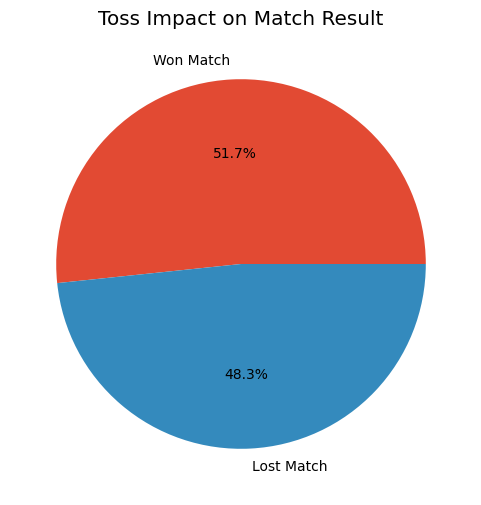

In [31]:
import matplotlib.pyplot as plt

toss_win = (
    df_matches["toss_match_win"]
    .value_counts(normalize=True) * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    toss_win,
    labels=["Won Match", "Lost Match"],
    autopct="%1.1f%%"
)

plt.title("Toss Impact on Match Result")

plt.show()

**Insight:**

Teams that won the toss also won the match in 51.65% of IPL matches, while teams that lost the toss won 48.35% of matches. The difference between the two outcomes is relatively small, indicating that winning the toss provides only a slight advantage. Overall, match results appear to be influenced more by team performance, player execution, and match conditions than by the toss outcome alone.

**Analysis 3:** Top 10 Run Scorers

**Objective:**
Identify the batsmen who have scored the highest number of runs
in IPL history.

In [32]:
top_run = (df_balls.groupby("batter")["batter_runs"].sum()
   .sort_values(ascending=False)
   .head(10)
   .reset_index()
)
top_run

,batter,batter_runs
0,V Kohli,9050
1,RG Sharma,7185
2,S Dhawan,6769
3,DA Warner,6567
4,KL Rahul,5668
5,SK Raina,5536
6,MS Dhoni,5439
7,AM Rahane,5194
8,AB de Villiers,5181
9,SV Samson,5008


**Insight:**

Virat Kohli is the highest run-scorer in IPL history with 9,050 runs, significantly ahead of all other batsmen in the dataset. Rohit Sharma and Shikhar Dhawan occupy the second and third positions respectively, highlighting their long-term consistency in the tournament. The presence of players such as MS Dhoni, AB de Villiers, and David Warner in the top 10 demonstrates their sustained batting excellence across multiple IPL seasons.

**Analysis 4:** Top 10 Six Hitters in IPL History

**Objective:**
Identify the batsmen who have hit the most sixes in IPL history

In [33]:
top_sixes = (df_balls[df_balls["batter_runs"]== 6]
             .groupby("batter")["batter_runs"]
             .count()
             .sort_values(ascending=False)
             .head(10)
             .reset_index() )
top_sixes


,batter,batter_runs
0,CH Gayle,359
1,RG Sharma,311
2,V Kohli,307
3,MS Dhoni,264
4,AB de Villiers,253
5,DA Warner,236
6,SV Samson,234
7,KL Rahul,232
8,KA Pollard,224
9,AD Russell,223


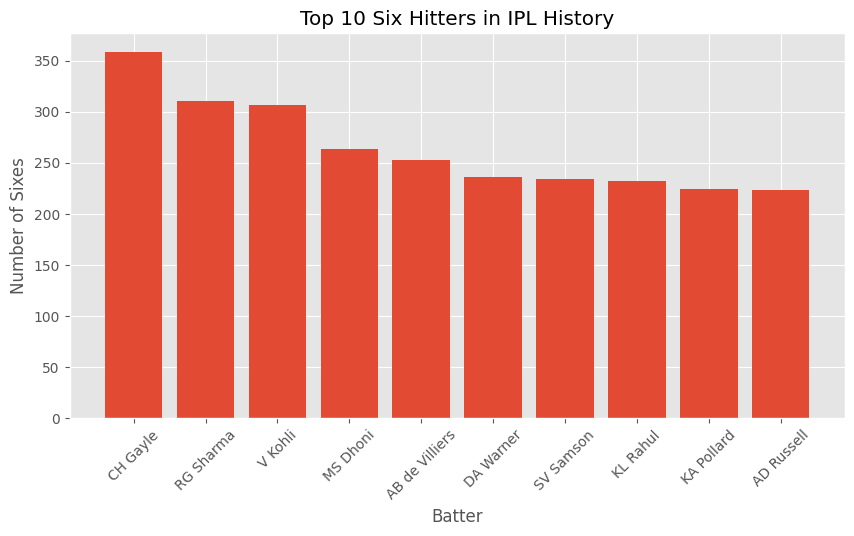

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top_sixes["batter"], top_sixes["batter_runs"])

plt.title("Top 10 Six Hitters in IPL History")
plt.xlabel("Batter")
plt.ylabel("Number of Sixes")

plt.xticks(rotation=45)

plt.show()

**Insight:**

Chris Gayle is the most destructive power hitter in IPL history, leading the chart with 359 sixes. Rohit Sharma and Virat Kohli occupy the second and third positions respectively, demonstrating not only consistency in run-scoring but also their ability to score quickly through boundary hitting. The presence of players such as MS Dhoni, AB de Villiers, Kieron Pollard, and Andre Russell highlights the importance of power-hitting in T20 cricket.

**Analysis 5:** Top 10 Wicket Takers

**Objective:**
Identify the bowlers who have taken the highest number of wickets
in IPL history.

In [35]:
df_balls["wicket_kind"].value_counts()

,count
wicket_kind,
None,273886
caught,9056
bowled,2407
run out,1176
lbw,873
caught and bowled,399
stumped,382
retired hurt,19
hit wicket,18


In [36]:
valid_wickets = df_balls[~df_balls["wicket_kind"].isin([
    "run out",
    "retired hurt",
    "retired out",
    "obstructing the field"
])
]
top_wickets = (
    valid_wickets.groupby("bowler")["is_wicket"]
               .sum()
               .sort_values(ascending=False)
               .head(10)
               )
top_wickets

,is_wicket
bowler,
YS Chahal,228
B Kumar,215
SP Narine,201
PP Chawla,192
JJ Bumrah,188
R Ashwin,187
DJ Bravo,183
RA Jadeja,177
A Mishra,174


**Insight:**

Yuzvendra Chahal is the leading wicket-taker in IPL history with 228 wickets, highlighting his consistency and effectiveness as a spinner across multiple seasons. Bhuvneshwar Kumar and Sunil Narine rank second and third respectively, demonstrating their long-term impact as wicket-taking bowlers. The presence of both pace bowlers and spinners in the top 10 indicates that success in the IPL is not limited to a single bowling style.

**Analysis 6**: Runs by Season

**Objective**:
Analyze how total runs scored in the IPL have changed across seasons.

In [37]:
season_runs = pd.merge(
    df_balls,
    df_matches[["match_id", "season"]],
    on="match_id",
    how="left"
)

runs_by_season = (
    season_runs.groupby("season")["total_runs"]
    .sum()
    .sort_index()
)
runs_by_season

,total_runs
season,
2008,17937
2009,16353
2010,18883
2011,21154
2012,22453
2013,22602
2014,18931
2015,18353
2016,18862


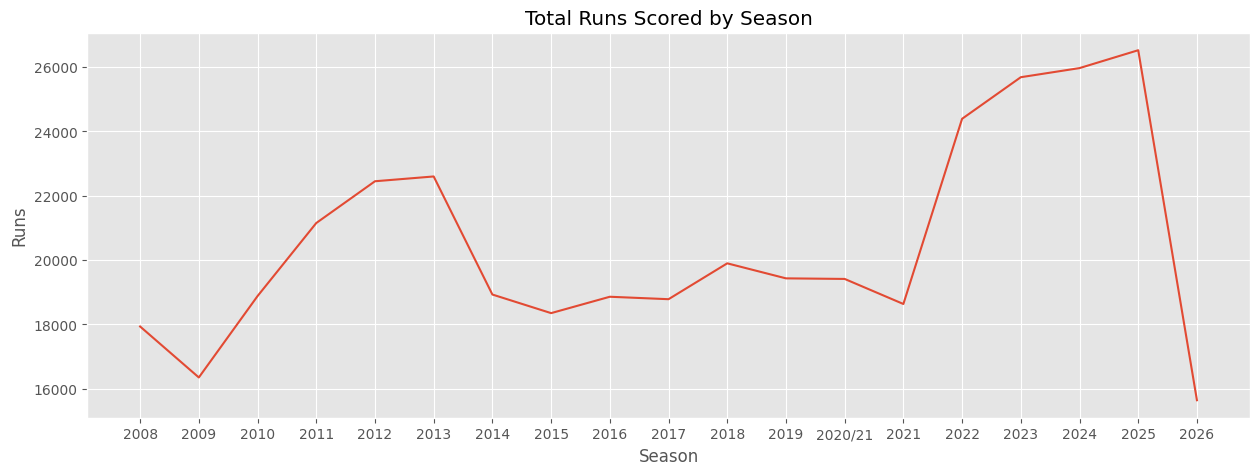

In [38]:
plt.figure(figsize=(15,5))

plt.plot(
    runs_by_season.index,
    runs_by_season.values
)

plt.title("Total Runs Scored by Season")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

**Insight:**

The total runs scored in the IPL have generally increased over time, indicating a shift toward more aggressive batting and higher-scoring matches. While early IPL seasons (2008–2017) typically recorded between 16,000 and 22,000 runs, recent seasons have consistently crossed 24,000 runs. The highest total was recorded in 2025 with 26,527 runs, reflecting the evolution of T20 cricket toward power-hitting, higher strike rates, and more attacking batting strategies.

**Note:**

The 2026 season has been excluded from the trend analysis because the dataset contains incomplete season data. Including partial-season data could lead to misleading conclusions and an inaccurate representation of scoring trends.

**Analysis 7**: Orange Cap Winners by Season

**Objective:**
Identify the highest run-scoring batsman in each IPL season and analyze batting dominance across different years.

In [39]:
season_ball = pd.merge(
    df_balls,
    df_matches[["match_id", "season"]],
    on="match_id",
    how = "left"
)
season_runs = (season_ball.groupby(["season","batter"])["batter_runs"]
.sum()
.reset_index()
)
season_runs.head()

orange_cap = (season_runs.loc[
    season_runs.groupby("season")["batter_runs"].idxmax()])

**Insight:**

The Orange Cap winners have varied across IPL seasons, highlighting the emergence of different batting stars over time. Players such as Chris Gayle, David Warner, and Virat Kohli have dominated multiple seasons, while newer players like Shubman Gill and B Sai Sudharsan have emerged as top performers in recent years.

**Note:** The 2026 season contains incomplete data and has not been considered for comparison with completed seasons.

**Analysis 8**: Cities Hosting the Most IPL Matches

**Objective:**
Identify the cities that have hosted the highest number of IPL matches.

In [40]:
top_cities = (df_matches["city"]
              .value_counts()
              .head(5)
)

top_cities

,count
city,
Mumbai,185
Kolkata,104
Delhi,101
Chennai,95
Hyderabad,87


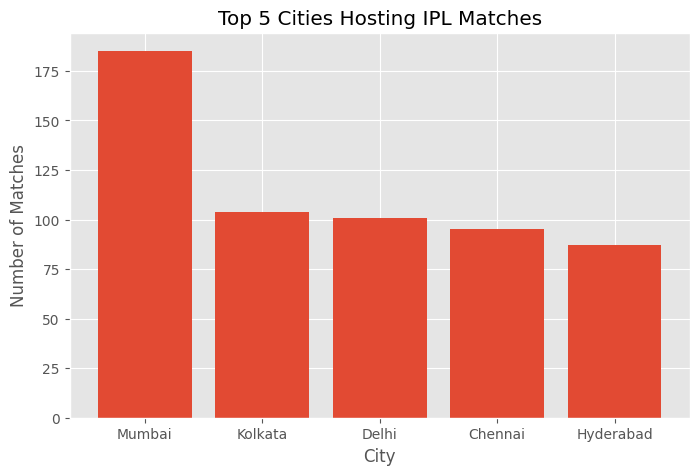

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(top_cities.index, top_cities.values)

plt.title("Top 5 Cities Hosting IPL Matches")
plt.xlabel("City")
plt.ylabel("Number of Matches")

plt.show()

**Insight:**

Mumbai has hosted the highest number of IPL matches (185), significantly more than any other city. Kolkata, Delhi, Chennai, and Hyderabad also rank among the most important IPL host cities, highlighting their strong cricket infrastructure and consistent involvement in the tournament.

**Analysis 9:** Most Player of the Match Awards

**Objective:**
Identify the players who have won the highest number of Player of the Match awards in IPL history.

In [50]:
import pandas as pd

pom_df = df_matches.copy()

pom_df["player_of_match"] = pd.to_numeric(
    pom_df["player_of_match"],
    errors="coerce"
)

pom_df = pom_df.dropna(subset=["player_of_match"])

pom_df["player_of_match"] = pom_df["player_of_match"].astype("int64")

pom = pd.merge(
    pom_df,
    df_player[["player_id", "player_name"]],
    left_on="player_of_match",
    right_on="player_id",
    how="left"
)

top_pom = (
    pom["player_name"]
    .value_counts()
    .head(10)
)

print(top_pom)

player_name
AB de Villiers    25
CH Gayle          22
RG Sharma         21
V Kohli           20
MS Dhoni          18
DA Warner         18
RA Jadeja         17
SP Narine         17
KL Rahul          17
AD Russell        16
Name: count, dtype: int64


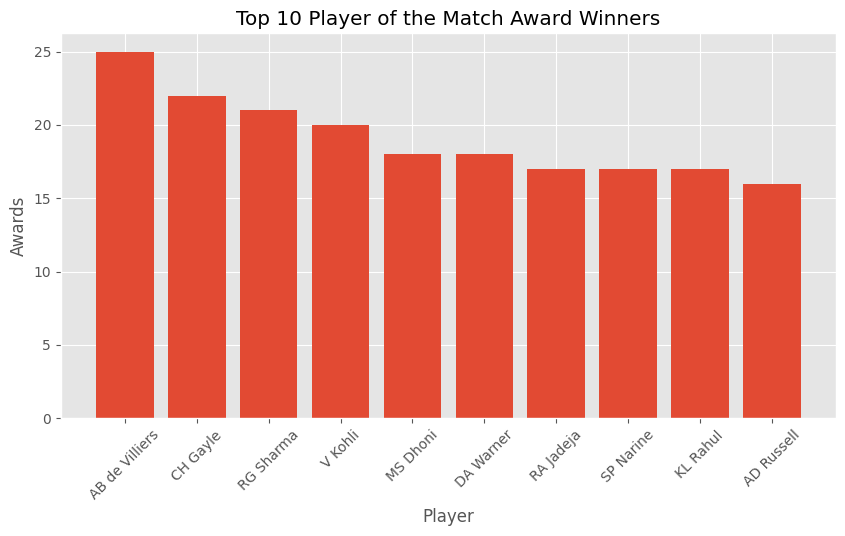

In [49]:
plt.figure(figsize=(10,5))

plt.bar(top_pom.index, top_pom.values)

plt.title("Top 10 Player of the Match Award Winners")
plt.xlabel("Player")
plt.ylabel("Awards")

plt.xticks(rotation=45)

plt.show()

**Insight:**

AB de Villiers has won the most Player of the Match awards (25), highlighting his ability to deliver match-winning performances consistently. Players such as Chris Gayle, Rohit Sharma, and Virat Kohli also feature prominently, reflecting their significant impact on IPL matches over the years.


**Analysis 10:** Highest Team Scores in IPL History

**Objective**
Identify the highest team totals scored in a single innings in IPL history.

In [46]:
highest_scores = (
    df_balls.groupby(
        ["match_id", "innings", "team_batting"]
    )["total_runs"]
    .sum()
    .reset_index()
    .sort_values("total_runs", ascending=False)
    .head(10)
)

highest_scores
highest_scores = pd.merge(
    highest_scores,
    df_team[["team_id", "team_name"]],
    left_on="team_batting",
    right_on="team_id",
    how="left"
)
highest_scores[
    ["team_name", "total_runs"]
].head(10)

,team_name,total_runs
0,Sunrisers Hyderabad,287
1,Sunrisers Hyderabad,286
2,Sunrisers Hyderabad,278
3,Sunrisers Hyderabad,277
4,Kolkata Knight Riders,272
5,Sunrisers Hyderabad,266
6,Punjab Kings,265
7,Delhi Capitals,264
8,Royal Challengers Bangalore,263
9,Punjab Kings,262


**Insight:**

Sunrisers Hyderabad dominate the list of highest team scores in IPL history, occupying five of the top ten positions, including the record score of 287 runs. This highlights their aggressive batting approach and ability to post massive totals in recent seasons.

**Analysis:11** Distribution of Runs per Ball

**Objective:**
What is the distribution of runs scored per ball in IPL matches, and which run outcomes occur most frequently?

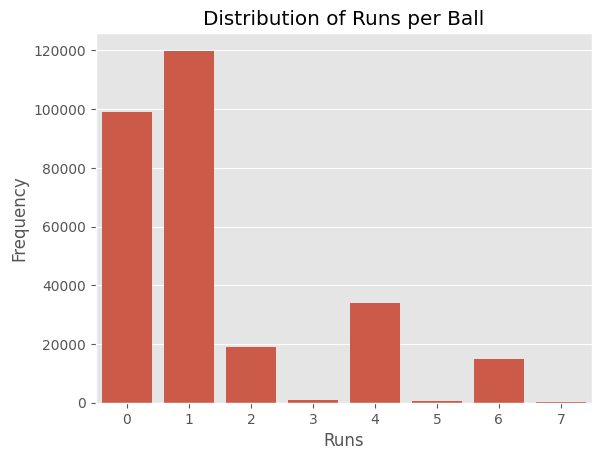

In [47]:
sns.countplot(x="total_runs", data=df_balls)

plt.title("Distribution of Runs per Ball")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

**Insight:**

The analysis shows that 0-run and 1-run deliveries are the most common outcomes in IPL matches, indicating that most balls result in either a dot ball or a single run. The frequency of deliveries decreases as the number of runs scored increases. While 4s and 6s occur less frequently, they contribute significantly to increasing team totals and play a crucial role in T20 batting strategies.

**Final Conclusion**

The analysis reveals the evolution of IPL into a high-scoring tournament, with increasing run totals, record-breaking team scores, and the consistent dominance of several elite batsmen and bowlers. The project demonstrates how data analytics can be used to extract actionable insights from large sports datasets.